In [3]:
import pandas as pd
print(pd.__version__)
import requests
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv"
response = requests.get(url)
open("course_lead_scoring.csv", "wb").write(response.content)

df = pd.read_csv("course_lead_scoring.csv")
df.head()

2.3.2


,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In this dataset our desired target for classification task will be "converted" variable, true or false - has the client signed up to the platform or not.

Data preparation
Check if the missing values are presented in the features.
If there are missing values:
- For caterogiral features, replace them with 'NA'
- For numerical features, replace with with 0.0

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].fillna('NA')
numerical_columns = df.select_dtypes(include=['number']).columns
df[numerical_columns] = df[numerical_columns].fillna(0.0)
numerical_columns = numerical_columns.drop('converted')


### Question 1

What is the most frequent observation (mode) for the column `industry`?

- `NA`
- `technology`
- `healthcare`
- `retail` <----

In [5]:
print(df['industry'].mode())

0    retail
Name: industry, dtype: object


### Question 2

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset. 
In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- `interaction_count` and `lead_score`
- `number_of_courses_viewed` and `lead_score`
- `number_of_courses_viewed` and `interaction_count`
- `annual_income` and `interaction_count` <----

Only consider the pairs above when answering this question.

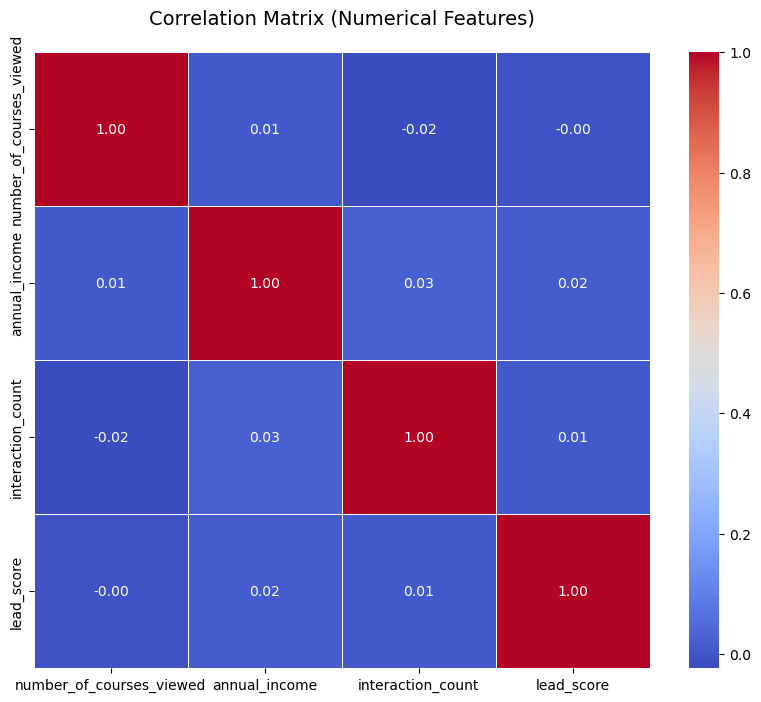

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # mostra i valori numerici
    fmt=".2f",         # due cifre decimali
    cmap="coolwarm",   # palette
    square=True,       # celle quadrate
    linewidths=0.5     # spazi tra celle
)
plt.title("Correlation Matrix (Numerical Features)", fontsize=14, pad=20)
plt.show()


### Split the data

* Split your data in train/val/test sets with 60%/20%/20% distribution.
* Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
* Make sure that the target value `y` is not in your dataframe.


In [7]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
y_train = df_train['converted']
x_train = df_train.drop(columns=['converted'])
y_val = df_val['converted']
x_val = df_val.drop(columns=['converted'])
y_test = df_test['converted']
x_test = df_test.drop(columns=['converted']) 




### Question 3

* Calculate the mutual information score between `y` and other categorical variables in the dataset. Use the training set only.
* Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?
  
- `industry`
- `location`
- `lead_source` <----
- `employment_status`

In [8]:
from sklearn.metrics import mutual_info_score
def calculate_mi(series):
    return mutual_info_score(series, y_train)

df_mi = df_train[categorical_columns].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')


display(df_mi)

,MI
lead_source,0.035396
employment_status,0.012938
industry,0.011575
location,0.004464


### Question 4

* Now let's train a logistic regression.
* Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
* Fit the model on the training dataset.
    - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
* Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.64
- 0.74. <----
- 0.84
- 0.94


In [9]:
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


model = Pipeline(steps=[
    ('vectorizer', DictVectorizer(sparse=False)),
    ('classifier', LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42))
])

X_train = x_train.to_dict(orient='records')
X_val = x_val.to_dict(orient='records')

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]
prediction = y_pred > 0.5
acc = accuracy_score(y_val, prediction)

print(f"Accuracy: {acc:.2f}")

Accuracy: 0.70


### Question 5 

* Let's find the least useful feature using the *feature elimination* technique.
* Train a model using the same features and parameters as in Q4 (without rounding).
* Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
* For each feature, calculate the difference between the original accuracy and the accuracy without the feature. 

Which of following feature has the smallest difference?

- `'industry'` <----
- `'employment_status'`
- `'lead_score'`

> **Note**: The difference doesn't have to be positive.


In [10]:
feature_names = x_train.columns
accuracy_drop = {}
baseline_acc = acc
for feature in feature_names:
    model = Pipeline(steps=[
    ('vectorizer', DictVectorizer(sparse=False)),
    ('classifier', LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42))
    ])
    # Remove one feature
    X_reduced = x_train.drop(columns=[feature])
   
    X_train = X_reduced.to_dict(orient='records')

    model.fit(X_train, y_train)

    x_val_reduced = x_val.drop(columns=[feature])
    X_val = x_val_reduced.to_dict(orient='records')

    acc = model.score(X_val, y_val)
    print(f"Accuracy: {acc:.2f}")

    # Record accuracy drop
    accuracy_drop[feature] = baseline_acc - acc

# --- 4. Summarize results ---
accuracy_diff = pd.Series(accuracy_drop).sort_values(ascending=True)
print("\nAccuracy difference (baseline - without feature):")
print(accuracy_diff)

Accuracy: 0.70
Accuracy: 0.70
Accuracy: 0.56
Accuracy: 0.85
Accuracy: 0.70
Accuracy: 0.71
Accuracy: 0.56
Accuracy: 0.71

Accuracy difference (baseline - without feature):
annual_income              -0.153584
location                   -0.010239
lead_score                 -0.006826
lead_source                -0.003413
industry                    0.000000
employment_status           0.003413
number_of_courses_viewed    0.143345
interaction_count           0.143345
dtype: float64


### Question 6

* Now let's train a regularized logistic regression.
* Let's try the following values of the parameter `C`: `[0.01, 0.1, 1, 10, 100]`.
* Train models using all the features as in Q4.
* Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

- 0.01 <----
- 0.1
- 1
- 10
- 100

> **Note**: If there are multiple options, select the smallest `C`.


In [11]:
C_vector = [0.01, 0.1, 1, 10, 100, 1000, 0.00001]

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
y_train = df_train['converted']
x_train = df_train.drop(columns=['converted'])
y_val = df_val['converted']
x_val = df_val.drop(columns=['converted'])
y_test = df_test['converted']
x_test = df_test.drop(columns=['converted']) 
X_train = x_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(X_train)
val_dict = x_val.to_dict(orient='records')
X_val = dv.transform(val_dict)
X_test = dv.transform(x_test.to_dict(orient='records'))

save_c_accuracy = {}
for c_trial in C_vector:
    model = LogisticRegression(solver='liblinear', C=c_trial, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    prediction = y_pred > 0.5
    acc = accuracy_score(y_val, prediction)
    print(f"Accuracy: {acc:.3f}")
    # Record accuracy for that C
    save_c_accuracy[c_trial] = acc

c_accuracy = pd.Series(save_c_accuracy).sort_index(ascending=False)
print("\nAccuracy for each experiment about C:")
print(c_accuracy)

Accuracy: 0.700
Accuracy: 0.700
Accuracy: 0.700
Accuracy: 0.700
Accuracy: 0.700
Accuracy: 0.700
Accuracy: 0.556

Accuracy for each experiment about C:
1000.00000    0.699659
100.00000     0.699659
10.00000      0.699659
1.00000       0.699659
0.10000       0.699659
0.01000       0.699659
0.00001       0.556314
dtype: float64
